In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Les données (X=phrases, y= étiquettes: 1 positif, 0 négatif)

sentences = [
    "Ce film est magnifique",
    "quel neau chef d'oeuvre",
    "j'ai adoré l'histoire",
    "vraiment incroyable et beau",
    "c'est une perte de temps",
    "le scnario est nul",
    "je n'ai pas aimé du tout",
    "vraiment décevant et mauvais"
]

labels=[1,1,1,1,0,0,0,0]

In [ ]:
tokenizer = Tokenizer(num_words=100)
tokenizer.fit_on_texts(sentences)

word_index = tokenizer.word_index
print(word_index)

sequences= tokenizer.texts_to_sequences(sentences)
print("Sequence générées(avec num_words= 100) :")
print(sentences, ':', sequences)
print("-"*35)

{'est': 1, 'vraiment': 2, 'et': 3, 'ce': 4, 'film': 5, 'magnifique': 6, 'quel': 7, 'neau': 8, 'chef': 9, "d'oeuvre": 10, "j'ai": 11, 'adoré': 12, "l'histoire": 13, 'incroyable': 14, 'beau': 15, "c'est": 16, 'une': 17, 'perte': 18, 'de': 19, 'temps': 20, 'le': 21, 'scnario': 22, 'nul': 23, 'je': 24, "n'ai": 25, 'pas': 26, 'aimé': 27, 'du': 28, 'tout': 29, 'décevant': 30, 'mauvais': 31}
Sequence générées(avec num_words= 100) :
['Ce film est magnifique', "quel neau chef d'oeuvre", "j'ai adoré l'histoire", 'vraiment incroyable et beau', "c'est une perte de temps", 'le scnario est nul', "je n'ai pas aimé du tout", 'vraiment décevant et mauvais'] : [[4, 5, 1, 6], [7, 8, 9, 10], [11, 12, 13], [2, 14, 3, 15], [16, 17, 18, 19, 20], [21, 22, 1, 23], [24, 25, 26, 27, 28, 29], [2, 30, 3, 31]]
-----------------------------------


In [ ]:
tokenizer_oov = Tokenizer(num_words=100, oov_token="<unk>")
tokenizer_oov.fit_on_texts(sentences)
print("--- 4. BONUS : TEST OOV ---")
print("Nouvel index (num_words=100, avec <unk>):")
print(tokenizer_oov.word_index)
print("-"*35)

--- 4. BONUS : TEST OOV ---
Nouvel index (num_words=100, avec <unk>):
{'<unk>': 1, 'est': 2, 'vraiment': 3, 'et': 4, 'ce': 5, 'film': 6, 'magnifique': 7, 'quel': 8, 'neau': 9, 'chef': 10, "d'oeuvre": 11, "j'ai": 12, 'adoré': 13, "l'histoire": 14, 'incroyable': 15, 'beau': 16, "c'est": 17, 'une': 18, 'perte': 19, 'de': 20, 'temps': 21, 'le': 22, 'scnario': 23, 'nul': 24, 'je': 25, "n'ai": 26, 'pas': 27, 'aimé': 28, 'du': 29, 'tout': 30, 'décevant': 31, 'mauvais': 32}
-----------------------------------


In [ ]:
sequences_oov = tokenizer_oov.texts_to_sequences(sentences)
print("\n Séquence pour 'i love my dog' :")
print(sequences_oov)
print("-"*35)


 Séquence pour 'i love my dog' :
[[5, 6, 2, 7], [8, 9, 10, 11], [12, 13, 14], [3, 15, 4, 16], [17, 18, 19, 20, 21], [22, 23, 2, 24], [25, 26, 27, 28, 29, 30], [3, 31, 4, 32]]
-----------------------------------


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
padded= pad_sequences(sequences_oov,maxlen=5)
print("\nWord Index=" , word_index)
print("\nSequences=" , sequences_oov)
print("\nPadded Sequences:")
print(padded)


Word Index= {'est': 1, 'vraiment': 2, 'et': 3, 'ce': 4, 'film': 5, 'magnifique': 6, 'quel': 7, 'neau': 8, 'chef': 9, "d'oeuvre": 10, "j'ai": 11, 'adoré': 12, "l'histoire": 13, 'incroyable': 14, 'beau': 15, "c'est": 16, 'une': 17, 'perte': 18, 'de': 19, 'temps': 20, 'le': 21, 'scnario': 22, 'nul': 23, 'je': 24, "n'ai": 25, 'pas': 26, 'aimé': 27, 'du': 28, 'tout': 29, 'décevant': 30, 'mauvais': 31}

Sequences= [[5, 6, 2, 7], [8, 9, 10, 11], [12, 13, 14], [3, 15, 4, 16], [17, 18, 19, 20, 21], [22, 23, 2, 24], [25, 26, 27, 28, 29, 30], [3, 31, 4, 32]]

Padded Sequences:
[[ 0  5  6  2  7]
 [ 0  8  9 10 11]
 [ 0  0 12 13 14]
 [ 0  3 15  4 16]
 [17 18 19 20 21]
 [ 0 22 23  2 24]
 [26 27 28 29 30]
 [ 0  3 31  4 32]]


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(solver='liblinear')

model.fit(padded, labels)

y_pred = model.predict(padded)

accuracy = accuracy_score(labels, y_pred)
print(f"Model Accuracy (on training data): {accuracy:.2f}")

Model Accuracy (on training data): 1.00


In [ ]:
import json
import numpy as np
import pandas as pd
import urllib
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

#1. chargement des données
url='https://storage.googleapis.com/learning-datasets/sarcasm.json'
data=json.loads(urllib.request.urlopen(url).read())
sentences=[]
labels=[]
df=pd.DataFrame(data)

In [ ]:
df.head(10)

,article_link,headline,is_sarcastic
0,https://www.huffingtonpost.com/entry/versace-b...,former versace store clerk sues over secret 'b...,0
1,https://www.huffingtonpost.com/entry/roseanne-...,the 'roseanne' revival catches up to our thorn...,0
2,https://local.theonion.com/mom-starting-to-fea...,mom starting to fear son's web series closest ...,1
3,https://politics.theonion.com/boehner-just-wan...,"boehner just wants wife to listen, not come up...",1
4,https://www.huffingtonpost.com/entry/jk-rowlin...,j.k. rowling wishes snape happy birthday in th...,0
5,https://www.huffingtonpost.com/entry/advancing...,advancing the world's women,0
6,https://www.huffingtonpost.com/entry/how-meat-...,the fascinating case for eating lab-grown meat,0
7,https://www.huffingtonpost.com/entry/boxed-col...,"this ceo will send your kids to school, if you...",0
8,https://politics.theonion.com/top-snake-handle...,top snake handler leaves sinking huckabee camp...,1
9,https://www.huffingtonpost.com/entry/fridays-m...,friday's morning email: inside trump's presser...,0


In [ ]:
df.shape

(26709, 3)

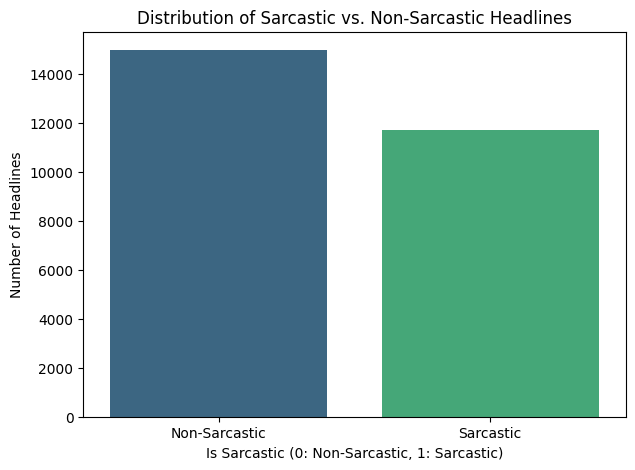

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sarcasm_counts = df['is_sarcastic'].value_counts()

plt.figure(figsize=(7, 5))
sns.barplot(x=sarcasm_counts.index, y=sarcasm_counts.values, hue=sarcasm_counts.index, palette='viridis', legend=False)
plt.title('Distribution of Sarcastic vs. Non-Sarcastic Headlines')
plt.xlabel('Is Sarcastic (0: Non-Sarcastic, 1: Sarcastic)')
plt.ylabel('Number of Headlines')
plt.xticks(ticks=[0, 1], labels=['Non-Sarcastic', 'Sarcastic'])
plt.show()

In [ ]:
sentences=df['headline'].tolist()
labels=df['is_sarcastic'].tolist()

import nltk
from nltk.corpus import stopwords
import re

# Download stopwords if not already downloaded
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')

english_stopwords = set(stopwords.words('english'))

# Create a new list for processed sentences
processed_sentences = []

for i, sentence in enumerate(sentences):
    if labels[i] == 1: # Only process sarcastic sentences
        # Convert to lowercase and remove punctuation
        sentence = re.sub(r'[^\w\s]', '', sentence.lower()) # General punctuation removal
        words = sentence.split()
        filtered_words = [word for word in words if word not in english_stopwords]
        processed_sentences.append(' '.join(filtered_words))
    else:
        processed_sentences.append(sentence) # Keep non-sarcastic sentences as is

sentences = processed_sentences # Update the original sentences list

print("First 5 processed sentences (sarcastic ones should have stopwords removed):")
for i in range(5):
    print(f"- {sentences[i]} (Sarcastic: {labels[i]})")

First 5 processed sentences (sarcastic ones should have stopwords removed):
- former versace store clerk sues over secret 'black code' for minority shoppers (Sarcastic: 0)
- the 'roseanne' revival catches up to our thorny political mood, for better and worse (Sarcastic: 0)
- mom starting fear sons web series closest thing grandchild (Sarcastic: 1)
- boehner wants wife listen come alternative debtreduction ideas (Sarcastic: 1)
- j.k. rowling wishes snape happy birthday in the most magical way (Sarcastic: 0)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer_oov = Tokenizer(num_words=10000, oov_token="<unk>")
tokenizer_oov.fit_on_texts(sentences)
print("Tokenization for Sarcasm Dataset (with <unk> token):")
print("Word Index size:", len(tokenizer_oov.word_index))
print("Top 10 words:", list(tokenizer_oov.word_index.items())[:10])
print("-" * 35)

Tokenization for Sarcasm Dataset (with <unk> token):
Word Index size: 30397
Top 10 words: [('<unk>', 1), ('the', 2), ('to', 3), ('a', 4), ('of', 5), ('in', 6), ('for', 7), ('and', 8), ('new', 9), ('is', 10)]
-----------------------------------


In [ ]:
sequences = tokenizer_oov.texts_to_sequences(sentences)
print("First 5 sequences:")
for i in range(5):
    print(f"Original: {sentences[i][:50]}... -> Sequence: {sequences[i][:10]}...")
print("-" * 35)

First 5 sequences:
Original: former versace store clerk sues over secret 'black... -> Sequence: [272, 1, 785, 3566, 2251, 60, 353, 2509, 1, 7]...
Original: the 'roseanne' revival catches up to our thorny po... -> Sequence: [2, 1, 3289, 2687, 46, 3, 167, 8351, 394, 2876]...
Original: mom starting fear sons web series closest thing gr... -> Sequence: [118, 805, 855, 1579, 2039, 552, 4652, 187, 1]...
Original: boehner wants wife listen come alternative debtred... -> Sequence: [1461, 193, 400, 1787, 290, 3290, 1, 906]...
Original: j.k. rowling wishes snape happy birthday in the mo... -> Sequence: [1011, 856, 4653, 881, 1, 595, 567, 6, 2, 169]...
-----------------------------------


In [ ]:

max_sequence_len = max(len(seq) for seq in sequences)
print(f"Maximum sequence length: {max_sequence_len}")

padded_sequences = pad_sequences(sequences, maxlen=max_sequence_len, padding='post')

print("Padded Sequences shape:", padded_sequences.shape)
print("First 5 padded sequences (first 10 elements):")
for i in range(5):
    print(padded_sequences[i][:10])
print("-" * 35)

Maximum sequence length: 38
Padded Sequences shape: (26709, 38)
First 5 padded sequences (first 10 elements):
[ 272    1  785 3566 2251   60  353 2509    1    7]
[   2    1 3289 2687   46    3  167 8351  394 2876]
[ 118  805  855 1579 2039  552 4652  187    1    0]
[1461  193  400 1787  290 3290    1  906    0    0]
[1011  856 4653  881    1  595  567    6    2  169]
-----------------------------------


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {len(y_train)}")
print(f"y_test shape: {len(y_test)}")

X_train shape: (21367, 38)
X_test shape: (5342, 38)
y_train shape: 21367
y_test shape: 5342


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


model = LogisticRegression(solver='liblinear', max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy on Test Data: {accuracy:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Model Accuracy on Test Data: 0.6447

Classification Report:

              precision    recall  f1-score   support

           0       0.66      0.75      0.70      2996
           1       0.62      0.51      0.56      2346

    accuracy                           0.64      5342
   macro avg       0.64      0.63      0.63      5342
weighted avg       0.64      0.64      0.64      5342



In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Create a CountVectorizer to get Bag-of-Words representation
# We will use the 'sentences' list which already has stopwords removed for sarcastic headlines
vectorizer = CountVectorizer(max_features=10000) # Limiting features to match num_words in Tokenizer
X_bow = vectorizer.fit_transform(sentences)

print(f"Shape of Bag-of-Words matrix: {X_bow.shape}")
print(f"Vocabulary size (max_features): {len(vectorizer.vocabulary_)}")

Shape of Bag-of-Words matrix: (26709, 10000)
Vocabulary size (max_features): 10000


In [ ]:
X_train_bow, X_test_bow, y_train_bow, y_test_bow = train_test_split(X_bow, labels, test_size=0.2, random_state=42)

print(f"X_train_bow shape: {X_train_bow.shape}")
print(f"X_test_bow shape: {X_test_bow.shape}")
print(f"y_train_bow shape: {len(y_train_bow)}")
print(f"y_test_bow shape: {len(y_test_bow)}")

X_train_bow shape: (21367, 10000)
X_test_bow shape: (5342, 10000)
y_train_bow shape: 21367
y_test_bow shape: 5342


In [ ]:
model_bow = LogisticRegression(solver='liblinear', max_iter=1000)

model_bow.fit(X_train_bow, y_train_bow)

y_pred_bow = model_bow.predict(X_test_bow)

accuracy_bow = accuracy_score(y_test_bow, y_pred_bow)
print(f"Model Accuracy (BoW) on Test Data: {accuracy_bow:.4f}")
print("\nClassification Report (BoW):\n")
print(classification_report(y_test_bow, y_pred_bow))

Model Accuracy (BoW) on Test Data: 0.9678

Classification Report (BoW):

              precision    recall  f1-score   support

           0       1.00      0.95      0.97      2996
           1       0.94      1.00      0.96      2346

    accuracy                           0.97      5342
   macro avg       0.97      0.97      0.97      5342
weighted avg       0.97      0.97      0.97      5342



TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, log_loss
import numpy as np
import pandas as pd

In [ ]:
tfidf_vectorizer = TfidfVectorizer(max_features=10000) # You can adjust max_features as needed
X_tfidf_display = tfidf_vectorizer.fit_transform(sentences)

print(f"Shape of TF-IDF matrix: {X_tfidf_display.shape}")
print("Sample of TF-IDF matrix (first 5 rows, first 10 columns):\n")
# Convert to dense array to display a sample, as it's typically sparse
print(X_tfidf_display[:5, :10].toarray())

Shape of TF-IDF matrix: (26709, 10000)
Sample of TF-IDF matrix (first 5 rows, first 10 columns):

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [ ]:
X_train_tfidf_display, X_test_tfidf_display, y_train_tfidf, y_test_tfidf = train_test_split(X_tfidf_display, labels, test_size=0.2, random_state=42)

print(f"X_train_tfidf_display shape: {X_train_tfidf_display.shape}")
print(f"X_test_tfidf_display shape: {X_test_tfidf_display.shape}")
print(f"y_train_tfidf shape: {len(y_train_tfidf)}")
print(f"y_test_tfidf shape: {len(y_test_tfidf)}")

X_train_tfidf_display shape: (21367, 10000)
X_test_tfidf_display shape: (5342, 10000)
y_train_tfidf shape: 21367
y_test_tfidf shape: 5342


In [ ]:
model_tfidf = SGDClassifier(loss='log_loss', random_state=42)

model_tfidf.fit(X_train_tfidf_display, y_train_tfidf)

y_pred_tfidf = model_tfidf.predict(X_test_tfidf_display)

accuracy_tfidf = accuracy_score(y_test_tfidf, y_pred_tfidf)
print(f"Model Accuracy (TF-IDF) on Test Data: {accuracy_tfidf:.4f}")
print("\nClassification Report (TF-IDF):\n")
print(classification_report(y_test_tfidf, y_pred_tfidf))

Model Accuracy (TF-IDF) on Test Data: 0.9584

Classification Report (TF-IDF):

              precision    recall  f1-score   support

           0       1.00      0.93      0.96      2996
           1       0.91      1.00      0.95      2346

    accuracy                           0.96      5342
   macro avg       0.96      0.96      0.96      5342
weighted avg       0.96      0.96      0.96      5342



### Demonstration with a Single Sentence

In [ ]:
# 1. Define a new sentence
new_sentence = ["This is a truly brilliant and original idea, said no one ever."]

print(f"Original new sentence: {new_sentence[0]}")

Original new sentence: This is a truly brilliant and original idea, said no one ever.


### Résumé des Précisions des Modèles

Nous avons évalué trois approches de modélisation sur le dataset de sarcasme :

1.  **Modèle 1 : Tokenization Keras + Padding (Logistic Regression)**
    *   **Description :** Les phrases ont été tokenisées à l'aide de `Tokenizer` de Keras, puis padées pour uniformiser la longueur des séquences. Ces séquences numériques ont ensuite été utilisées pour entraîner un modèle de régression logistique.
    *   **Précision :** `accuracy` = **0.6447**

2.  **Modèle 2 : Bag-of-Words (Logistic Regression)**
    *   **Description :** Les phrases ont été transformées en représentations Bag-of-Words (BoW) à l'aide de `CountVectorizer`. Cette approche compte la fréquence des mots dans chaque document. Un modèle de régression logistique a été entraîné sur ces caractéristiques BoW.
    *   **Précision :** `accuracy_bow` = **0.9678**

3.  **Modèle 3 : TF-IDF (SGDClassifier)**
    *   **Description :** Les phrases ont été transformées en représentations TF-IDF à l'aide de `TfidfVectorizer`. Cette méthode pondère les mots en fonction de leur fréquence dans un document et de leur rareté dans le corpus. Un `SGDClassifier` a été entraîné sur ces caractéristiques TF-IDF.
    *   **Précision :** `accuracy_tfidf` = **0.9584**

**Observation :**
Les modèles basés sur **Bag-of-Words** et **TF-IDF** ont obtenu des précisions significativement plus élevées que le modèle utilisant la tokenization Keras avec padding. Cela suggère que la représentation basée sur la fréquence des mots (BoW) ou l'importance des mots (TF-IDF) est plus efficace pour ce problème de classification du sarcasme que la simple séquence d'indices de mots, au moins avec les modèles simples de régression logistique et SGDClassifier utilisés ici. Le modèle Bag-of-Words a légèrement surperformé le modèle TF-IDF dans cette configuration.

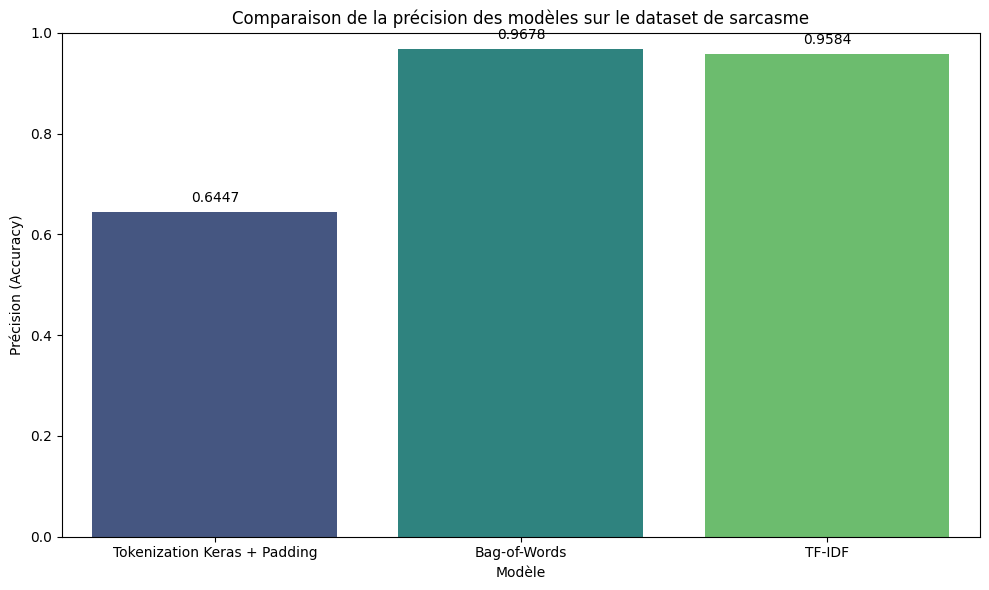

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for plotting
model_names = ['Tokenization Keras + Padding', 'Bag-of-Words', 'TF-IDF']
accuracies = [accuracy, accuracy_bow, accuracy_tfidf]
df_accuracies = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracies
})

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', hue='Model', data=df_accuracies, palette='viridis', legend=False)
plt.title('Comparaison de la précision des modèles sur le dataset de sarcasme')
plt.xlabel('Modèle')
plt.ylabel('Précision (Accuracy)')
plt.ylim(0, 1) # Accuracy is between 0 and 1

# Add accuracy values on top of the bars
for index, row in df_accuracies.iterrows():
    plt.text(row.name, row.Accuracy + 0.02, f'{row.Accuracy:.4f}', color='black', ha="center")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1. On sélectionne les premières phrases du corpus existant (df['review'])
# Si df n'est pas défini, on utilise un échantillon par défaut

# --- Méthode 1: Bag of Words ---
bow_vec = CountVectorizer(max_features=10)
bow_res = bow_vec.fit_transform(sentences).toarray()

# --- Méthode 2: TF-IDF ---
tfidf_vec = TfidfVectorizer(max_features=10)
tfidf_res = tfidf_vec.fit_transform(sentences).toarray()

# --- Méthode 3: Padding + Sequence ---
tokenizer_comp = Tokenizer(num_words=50, oov_token='<OOV>')
tokenizer_comp.fit_on_texts(sentences)
seqs = tokenizer_comp.texts_to_sequences(sentences)
padded_res = pad_sequences(seqs, maxlen=6, padding='post')

# Construction du tableau
comparison_data = []
for i, text in enumerate(sentences):
    comparison_data.append({
        'Ligne': f'Phrase {i+1}',
        'Texte Original': text,
        'Padding + Sequence': list(padded_res[i]),
        'Bag of Words': list(bow_res[i]),
        'TF-IDF': [round(x, 2) for x in tfidf_res[i]]
    })

df_final_comp = pd.DataFrame(comparison_data).set_index('Ligne')
display(df_final_comp)

,Texte Original,Padding + Sequence,Bag of Words,TF-IDF
Ligne,,,,
Phrase 1,former versace store clerk sues over secret 'b...,"[1, 1, 1, 7, 1, 1]","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0]","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
Phrase 2,the 'roseanne' revival catches up to our thorn...,"[1, 1, 7, 1, 8, 1]","[1, 1, 0, 0, 0, 0, 0, 1, 1, 0]","[0.57, 0.55, 0.0, 0.0, 0.0, 0.0, 0.0, 0.43, 0...."
Phrase 3,mom starting fear sons web series closest thin...,"[1, 1, 1, 1, 1, 1]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
Phrase 4,boehner wants wife listen come alternative deb...,"[1, 1, 1, 1, 1, 1]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
Phrase 5,j.k. rowling wishes snape happy birthday in th...,"[1, 6, 2, 1, 1, 1]","[0, 0, 1, 0, 0, 0, 0, 1, 0, 0]","[0.0, 0.0, 0.77, 0.0, 0.0, 0.0, 0.0, 0.64, 0.0..."
...,...,...,...,...
Phrase 26705,american politics in moral free-fall,"[1, 1, 6, 1, 1, 1]","[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]","[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
Phrase 26706,america's best 20 hikes,"[1, 1, 1, 1, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
Phrase 26707,reparations and obama,"[1, 8, 47, 0, 0, 0]","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


### Embedding des Mots avec Keras

Nous allons maintenant créer des vecteurs d'embedding pour nos phrases. Une couche d'embedding prend les indices entiers de nos mots (provenant de la tokenisation) et les convertit en vecteurs denses de taille fixe. Ces vecteurs peuvent être appris pendant l'entraînement d'un modèle de réseau de neurones.

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding

# Paramètres pour la couche d'embedding
# Utilisez la taille du vocabulaire du tokenizer_oov (num_words + 1 pour l'oov_token)
vocab_size = len(tokenizer_oov.word_index) + 1
embedding_dim = 8  # Dimension du vecteur d'embedding (ajustée à 8)
# input_length = max_sequence_len # Longueur maximale de nos séquences padées (38) - Dépérecé, Keras le déduira

print(f"Taille du vocabulaire: {vocab_size}")
print(f"Dimension de l'embedding: {embedding_dim}")
print(f"Longueur d'entrée (max_sequence_len): {max_sequence_len}") # On garde la variable pour information

# Créer un modèle simple avec une couche d'embedding
embedding_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim)
])

# La couche d'embedding n'a pas été entraînée, donc les poids sont initialisés aléatoirement.
# Pour les obtenir, nous devons 'prédire' sur nos séquences padées.
embeddings = embedding_model.predict(padded_sequences)

print("\nShape des vecteurs d'embedding (sentences, input_length, embedding_dim):")
print(embeddings.shape)

print("\nPremiers vecteurs d'embedding pour la première phrase (juste un extrait):")
# Afficher les 3 premiers mots de la première phrase et leurs vecteurs d'embedding
for i in range(min(3, embeddings.shape[1])):
    print(f"Mot {i+1} (dans la première phrase) Embedding: {embeddings[0][i][:5]}...") # Afficher les 5 premières valeurs du vecteur

print("\nIl est important de noter que sans entraînement, ces embeddings sont initialisés aléatoirement.")

Taille du vocabulaire: 30398
Dimension de l'embedding: 8
Longueur d'entrée (max_sequence_len): 38
835/835 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step

Shape des vecteurs d'embedding (sentences, input_length, embedding_dim):
(26709, 38, 8)

Premiers vecteurs d'embedding pour la première phrase (juste un extrait):
Mot 1 (dans la première phrase) Embedding: [ 0.01228936 -0.03331394 -0.01330869  0.04654625  0.03640011]...
Mot 2 (dans la première phrase) Embedding: [ 0.03053616  0.04703617 -0.01994282 -0.04516444  0.02117623]...
Mot 3 (dans la première phrase) Embedding: [ 0.04075934 -0.00619261  0.01459723 -0.0048569   0.01585554]...

Il est important de noter que sans entraînement, ces embeddings sont initialisés aléatoirement.


In [ ]:
# Choisissons la première phrase du dataset pour la démonstration
sentence_index = 0

original_sentence = sentences[sentence_index]
embedding_representation = embeddings[sentence_index]

print(f"Phrase Originale (Index {sentence_index}):\n'{original_sentence}'")
print(f"\nReprésentation d'Embedding pour cette phrase (Shape: {embedding_representation.shape}):")

# Affichons les 5 premiers vecteurs de mots de la phrase pour ne pas surcharger la sortie
for i in range(min(5, embedding_representation.shape[0])):
    print(f"  Mot {i+1} Embedding: {embedding_representation[i][:5]}...")

print("\nNote: Ceci est une partie des embeddings pour chaque mot de la séquence padée de la phrase. Les '0' sont pour le padding.")

Phrase Originale (Index 0):
'former versace store clerk sues over secret 'black code' for minority shoppers'

Représentation d'Embedding pour cette phrase (Shape: (38, 8)):
  Mot 1 Embedding: [ 0.01228936 -0.03331394 -0.01330869  0.04654625  0.03640011]...
  Mot 2 Embedding: [ 0.03053616  0.04703617 -0.01994282 -0.04516444  0.02117623]...
  Mot 3 Embedding: [ 0.04075934 -0.00619261  0.01459723 -0.0048569   0.01585554]...
  Mot 4 Embedding: [-0.00696646 -0.01960791 -0.02719283 -0.03535633 -0.01649332]...
  Mot 5 Embedding: [ 0.02978847 -0.01924573  0.01735485 -0.03025303  0.02262871]...

Note: Ceci est une partie des embeddings pour chaque mot de la séquence padée de la phrase. Les '0' sont pour le padding.


**Explication des colonnes et lignes obtenu avec l'embedding**

Au niveau de l'embedding, le modele prend chaque phrase, puis pour chaque phrase il prend chaque mot qu'il va projeter dans un espace de dimension qu'on va preciser, dans cet espace, chaque mot de la phrase est representer/noter sous certains features(caracctéristiques latentes) en quelques sortes (nombre de features=dimension de l'espace), ainsi si on choisit un espace de 8 dimensions, le mots aurra 8 colonnes dans cet espace et chaque colonne represente une feature(qu'on ne connait pas, c'est le modèle qui les choisit automatiquement au cours de l'entrainement), chaque mot est projetter sur ce même espace. donc apres embedding une phrasse est représenter par une phrase dont le nombre de ligne est le nombre de mot et le nombre de colonne est la dimension de l'espace.

Le pooling intervient ensuite pour transformer cette matrice en vecteur de taille la dimension de l'espace. Pour ce faire il prend pour chaque mot de la phrase la moyenne(mean pooling, max pooling, ....) de chaque caracteristiques latente. on obtient donc a la fin, pour une phrase un vecteur.

### Modèle avec embedding + ann et Pooling

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense
from tensorflow.keras.optimizers import Adam

# Définir les paramètres du modèle
vocab_size = len(tokenizer_oov.word_index) + 1 # Taille du vocabulaire
embedding_dim = 16 # Dimension du vecteur d'embedding (arbitraire, peut être ajustée)
max_sequence_len = padded_sequences.shape[1] # Longueur maximale des séquences padées

# Créer le modèle de réseau de neurones
model_embedding = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_sequence_len),
    GlobalAveragePooling1D(), # Effectue le pooling pour réduire chaque séquence à un seul vecteur
    Dense(1, activation='sigmoid') # Couche de sortie pour la classification binaire (sarcasme ou non)
])

# Compiler le modèle
model_embedding.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Afficher un résumé du modèle
model_embedding.summary()

# Convertir les labels en un tableau NumPy pour l'entraînement
labels_array = np.array(labels)

# Entraîner le modèle
history = model_embedding.fit(
    padded_sequences, labels_array,
    epochs=10, # Nombre d'époques d'entraînement
    validation_split=0.2, # Utiliser 20% des données pour la validation
    verbose=1 # Afficher la progression de l'entraînement
)

# Évaluer le modèle sur les données d'entraînement (ou de test si nous avions un ensemble séparé)
loss, accuracy_embedding = model_embedding.evaluate(padded_sequences, labels_array, verbose=0)
print(f"\nPrécision du modèle (Embedding + Global Average Pooling) sur les données d'entraînement: {accuracy_embedding:.4f}")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7917 - loss: 0.5762 - val_accuracy: 0.9238 - val_loss: 0.4130
Epoch 2/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9435 - loss: 0.3024 - val_accuracy: 0.9526 - val_loss: 0.2304
Epoch 3/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9557 - loss: 0.1866 - val_accuracy: 0.9644 - val_loss: 0.1635
Epoch 4/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9643 - loss: 0.1345 - val_accuracy: 0.9601 - val_loss: 0.1294
Epoch 5/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9707 - loss: 0.1047 - val_accuracy: 0.9721 - val_loss: 0.1083
Epoch 6/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9757 - loss: 0.0847 - val_accuracy: 0.9755 - val_loss: 0.0964
Epoch 7/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9794 - loss: 0.0704 - val_accuracy: 0.9772 - val_loss: 0.0864
Epoch 8/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9817 - loss: 0.0595 - val_accuracy: 0.

### Modèle avec Couche de Convolution (CNN) et Pooling

In [ ]:
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D

# Créer le modèle de réseau de neurones avec une couche de convolution
model_cnn = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_sequence_len),
    Conv1D(filters=128, kernel_size=5, activation='relu'), # Couche de convolution
    GlobalMaxPooling1D(), # Pooling pour réduire les dimensions après la convolution
    Dense(1, activation='sigmoid') # Couche de sortie pour la classification binaire
])

# Compiler le modèle
model_cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Afficher un résumé du modèle
model_cnn.summary()

# Entraîner le modèle
history_cnn = model_cnn.fit(
    padded_sequences, labels_array,
    epochs=10,
    validation_split=0.2,
    verbose=1
)

# Évaluer le modèle
loss_cnn, accuracy_cnn = model_cnn.evaluate(padded_sequences, labels_array, verbose=0)
print(f"\nPrécision du modèle (Embedding + CNN) sur les données d'entraînement: {accuracy_cnn:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9335 - loss: 0.1620 - val_accuracy: 0.9775 - val_loss: 0.0678
Epoch 2/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9883 - loss: 0.0359 - val_accuracy: 0.9788 - val_loss: 0.0679
Epoch 3/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9959 - loss: 0.0132 - val_accuracy: 0.9788 - val_loss: 0.0818
Epoch 4/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9984 - loss: 0.0050 - val_accuracy: 0.9736 - val_loss: 0.0976
Epoch 5/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9989 - loss: 0.0028 - val_accuracy: 0.9772 - val_loss: 0.1076
Epoch 6/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9995 - loss: 0.0019 - val_accuracy: 0.9764 - val_loss: 0.1194
Epoch 7/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9996 - loss: 0.0012 - val_accuracy: 0.9723 - val_loss: 0.1304
Epoch 8/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9997 - loss: 0.0011 - val_accuracy: 0

### Graphique Comparatif des Précisions des Modèles

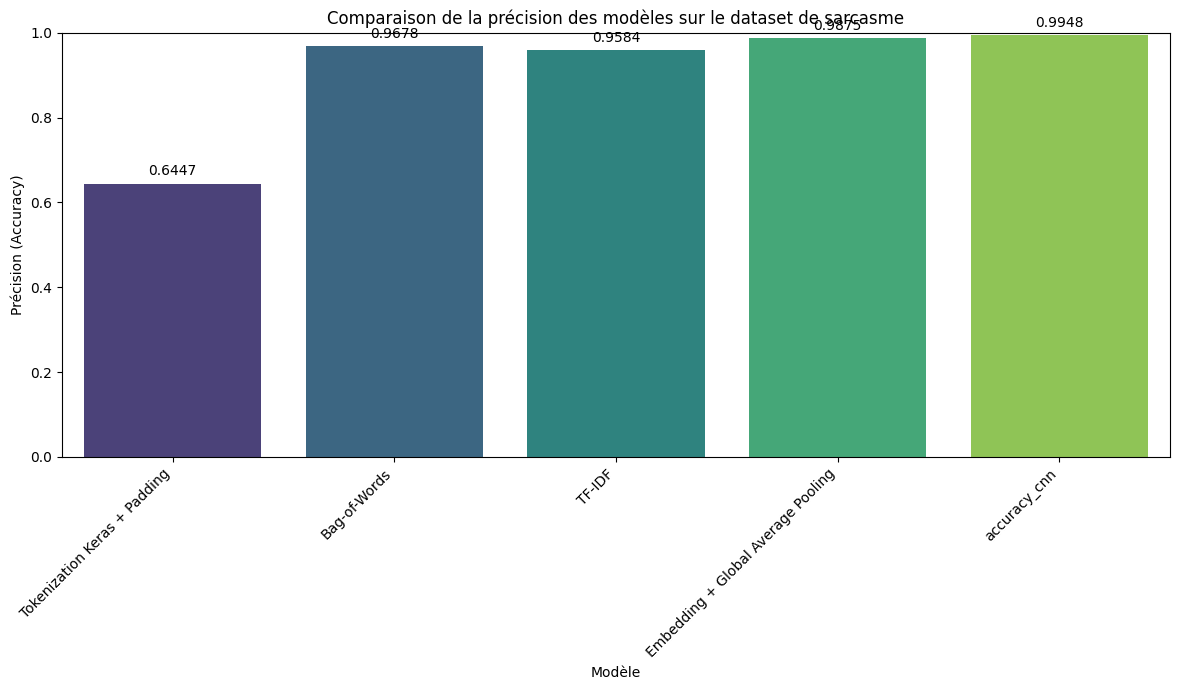

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for plotting
model_names = ['Tokenization Keras + Padding', 'Bag-of-Words', 'TF-IDF', 'Embedding + Global Average Pooling','accuracy_cnn']
accuracies = [accuracy, accuracy_bow, accuracy_tfidf, accuracy_embedding, accuracy_cnn]
df_accuracies_new_plot = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracies
})

# Create the bar plot
plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Accuracy', hue='Model', data=df_accuracies_new_plot, palette='viridis', legend=False)
plt.title('Comparaison de la précision des modèles sur le dataset de sarcasme')
plt.xlabel('Modèle')
plt.ylabel('Précision (Accuracy)')
plt.ylim(0, 1) # Accuracy is between 0 and 1

# Add accuracy values on top of the bars
for index, row in df_accuracies_new_plot.iterrows():
    plt.text(row.name, row.Accuracy + 0.02, f'{row.Accuracy:.4f}', color='black', ha="center")

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

###Fine tuning embedding statique (Glove)

### Téléchargement des Embeddings GloVe

Nous allons télécharger les embeddings GloVe pré-entraînés. Pour cet exemple, nous utiliserons la version `glove.6B.100d.txt` (100 dimensions, 6 milliards de tokens), qui est un bon compromis taille/performance. Assurez-vous d'avoir une connexion internet pour cette étape.

In [ ]:
# Téléchargement du fichier GloVe
# Cela peut prendre un certain temps en fonction de votre connexion
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

--2026-04-09 20:15:58--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-04-09 20:15:58--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-04-09 20:15:59--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

### Chargement des Embeddings GloVe

Maintenant, nous allons charger les vecteurs d'embedding à partir du fichier GloVe téléchargé et créer un dictionnaire qui mappe chaque mot à son vecteur d'embedding.

In [ ]:
embeddings_index = {}
with open('glove.6B.100d.txt', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print(f'Found {len(embeddings_index)} word vectors.')

Found 400000 word vectors.


### Création de la Matrice d'Embedding

Nous allons créer une matrice d'embedding où chaque ligne correspondra à un mot de notre vocabulaire (`tokenizer_oov.word_index`) et chaque colonne à une dimension de l'embedding GloVe. Les mots de notre vocabulaire qui ne sont pas trouvés dans GloVe seront initialisés à zéro.

In [ ]:
embedding_dim_glove = 100 # Dimension des embeddings GloVe que nous utilisons

embedding_matrix_glove = np.zeros((vocab_size, embedding_dim_glove))
for word, i in tokenizer_oov.word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        # Les mots non trouvés dans le vocabulaire GloVe resteront à zéro
        embedding_matrix_glove[i] = embedding_vector

print(f"Shape de la matrice d'embedding GloVe: {embedding_matrix_glove.shape}")

Shape de la matrice d'embedding GloVe: (30398, 100)


### Construction et Entraînement du Modèle avec Embeddings GloVe Statiques

Nous allons construire un nouveau modèle Keras en utilisant notre matrice d'embedding GloVe. La couche d'embedding sera définie avec `trainable=False` pour s'assurer que les poids GloVe restent statiques pendant l'entraînement.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

# Séparer les données en ensembles d'entraînement et de test
X_train_glove, X_test_glove, y_train_glove, y_test_glove = train_test_split(padded_sequences, labels_array, test_size=0.2, random_state=42)

# Créer le modèle
model_glove = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim_glove,
        weights=[embedding_matrix_glove],
        input_length=max_sequence_len,
        trainable=False # Important: les embeddings ne seront pas mis à jour pendant l'entraînement
    ),
    GlobalAveragePooling1D(),
    Dense(1, activation='sigmoid')
])

# Compiler le modèle
model_glove.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Afficher un résumé du modèle
model_glove.summary()

# Entraîner le modèle
history_glove = model_glove.fit(
    X_train_glove, y_train_glove,
    epochs=10,
    validation_data=(X_test_glove, y_test_glove),
    verbose=1
)

# Évaluer le modèle sur l'ensemble de test
loss_glove, accuracy_glove = model_glove.evaluate(X_test_glove, y_test_glove, verbose=0)
print(f"\nPrécision du modèle (GloVe + Global Average Pooling) sur les données de test: {accuracy_glove:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │     3,039,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,039,800 (11.60 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3,039,800 (11.60 MB)

Epoch 1/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5907 - loss: 0.6138 - val_accuracy: 0.6636 - val_loss: 0.5682
Epoch 2/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7382 - loss: 0.5350 - val_accuracy: 0.7772 - val_loss: 0.5085
Epoch 3/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8031 - loss: 0.4851 - val_accuracy: 0.8173 - val_loss: 0.4674
Epoch 4/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8241 - loss: 0.4497 - val_accuracy: 0.8334 - val_loss: 0.4376
Epoch 5/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8379 - loss: 0.4236 - val_accuracy: 0.8422 - val_loss: 0.4151
Epoch 6/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8448 - loss: 0.4034 - val_accuracy: 0.8476 - val_loss: 0.3974
Epoch 7/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8500 - loss: 0.3874 - val_accuracy: 0.8521 - val_loss: 0.3832
Epoch 8/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8550 - loss: 0.3743 - val_accuracy: 0.

### Mise à jour du Graphique Comparatif des Précisions des Modèles

Maintenant que nous avons entraîné et évalué le modèle avec les embeddings GloVe, nous allons mettre à jour le graphique comparatif pour inclure cette nouvelle précision.

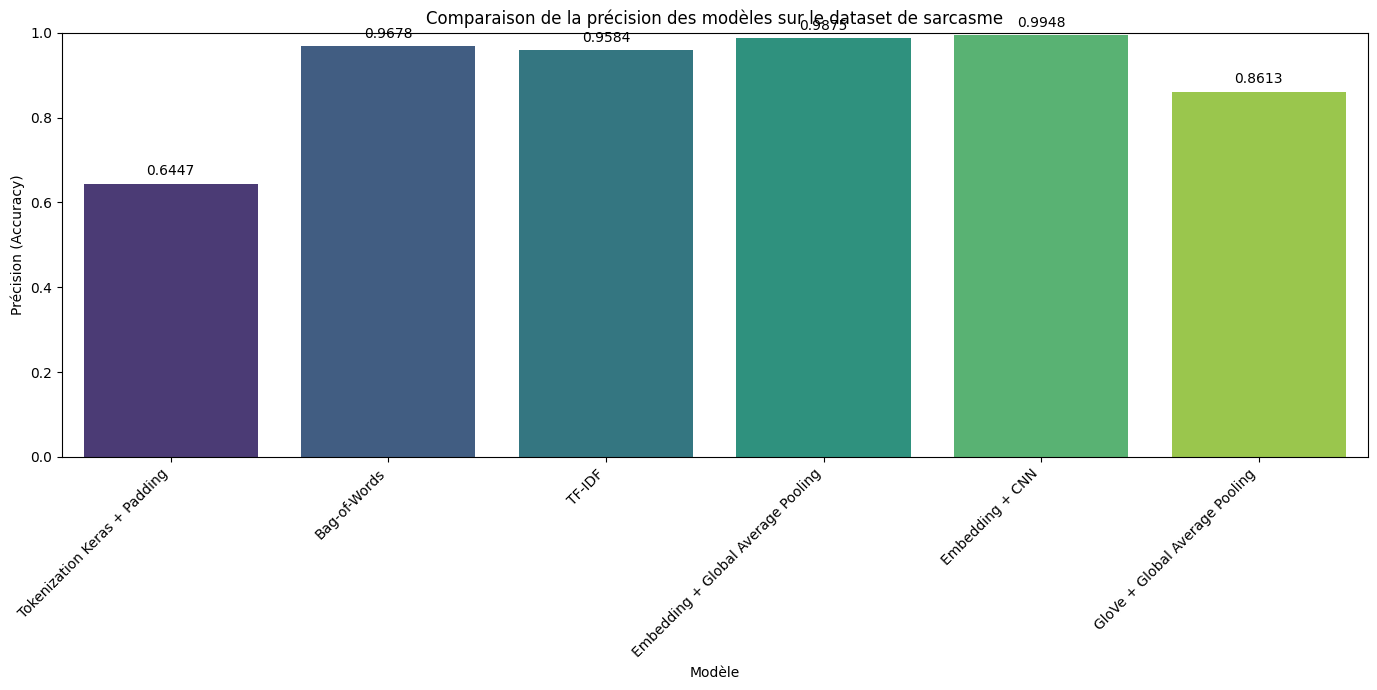

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for plotting
model_names = ['Tokenization Keras + Padding', 'Bag-of-Words', 'TF-IDF', 'Embedding + Global Average Pooling', 'Embedding + CNN', 'GloVe + Global Average Pooling']
accuracies = [accuracy, accuracy_bow, accuracy_tfidf, accuracy_embedding, accuracy_cnn, accuracy_glove]
df_accuracies_updated_plot = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracies
})

# Create the bar plot
plt.figure(figsize=(14, 7))
sns.barplot(x='Model', y='Accuracy', hue='Model', data=df_accuracies_updated_plot, palette='viridis', legend=False)
plt.title('Comparaison de la précision des modèles sur le dataset de sarcasme')
plt.xlabel('Modèle')
plt.ylabel('Précision (Accuracy)')
plt.ylim(0, 1) # Accuracy is between 0 and 1

# Add accuracy values on top of the bars
for index, row in df_accuracies_updated_plot.iterrows():
    plt.text(row.name, row.Accuracy + 0.02, f'{row.Accuracy:.4f}', color='black', ha="center")

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()